# Geopolitical Signal in Critical Minerals: Testing “Friendshoring” via Alternative Data + NLP

**Author:** Manoel Barroso Marques  
**Date:** March 2026  
**Environment:** Python 3 (Jupyter Notebook / VS Code)  
**LinkedIn:** [www.linkedin.com/in/manoel-barroso-433174216]  

---

### 1. Project Overview
This project tests whether **geopolitical sentiment shocks** proxied by real-time event data regarding **US–China tensions, export controls, and supply-chain disruptions** carry incremental predictive power for short-horizon returns in **critical minerals / rare-earth-linked equities**, with a special focus on **Brazil-related exposure** (*friendshoring* angle).

**Core question:**
> Do negative geopolitical sentiment shocks systematically act as a leading indicator for directional moves in critical-minerals equities, after controlling for broad market, sector, FX, and risk-regime factors?

### 2. Economic Rationale (The Thesis)
Critical minerals (including rare earths and lithium) sit at the center of strategic supply chains (electronics, defense, EVs). As geopolitical friction intensifies, capital may reprice:
* **Country risk and supply-chain concentration**, and
* The value of **alternative jurisdictions** (*"friendshoring"*) perceived as more neutral or resilient.

**Hypothesis:**
* **Negative geopolitical sentiment shocks** trigger immediate "risk-off" liquidity flights in the short term.
* **Improving sentiment or structural pivots** support relative outperformance, with potential differentiation for **Brazil-exposure names** as institutional investors rotate toward diversified supply chains.

### 3. Research Design (What Makes This Credible)

### 3.1 Universe (Tickers Defined Up Front)
To keep the study **replicable**, i define a transparent ticker list and apply liquidity/history filters (>= 3 years) before modeling.

* **Bucket A — Brazil Exposure (Core Target):** SGML (Sigma Lithium), ATLX (Atlas Lithium), BRVMF (Bravo Mining), BRE.AX (Brazilian Rare Earths). *Note: SGML is selected as the primary target variable for the predictive model.*
* **Bucket B — Global Peers (External Validity):** MP, LYC.AX, ALB, SQM, LAC, RIO, BHP, VALE.
* **Benchmarks & Risk Controls:** SPY (Broad equity), XME (Materials), REMX (Rare earths), LIT (Lithium theme), ^VIX (Risk regime), BRL=X (FX proxy).

### 3.2 Signal Construction (Geopolitical Sentiment Shock)
Instead of relying on generic retail news APIs, this research utilizes alternative military/institutional-grade data:
1.  **Extraction:** Query the **GDELT Project 2.0 API** for English-language headlines intersecting "Critical Minerals" and "US-China Geopolitics".
2.  **NLP Scoring:** Process each headline using **FinBERT** (Hugging Face) to extract positive/negative sentiment confidence.
3.  **Aggregation:** Compute a daily sentiment score.
4.  **Shock Generation:** Define a "shock" as a standardized deviation (Z-score) from a 21-day rolling baseline:
$$Shock_t = \frac{Sent_{t-1} - \mu(Sent_{t-21:t-2})}{\sigma(Sent_{t-21:t-2})}$$

### 3.3 Leakage Controls (No Look-Ahead Bias)
To strictly prevent information leakage, all features are temporally aligned. We use sentiment and macro closures from day $t-1$ to predict returns from day $t$. Contemporaneous data is explicitly dropped from the feature space.

### 4. Methodology & Stack
* **Data Acquisition:** `yfinance` (Market Data), `requests` / GDELT API (Alternative Data).
* **NLP:** `transformers` (FinBERT).
* **Predictive Modeling:** `LightGBM` classifier targeting binary directional moves ($D+1$).
* **Validation:** `TimeSeriesSplit` (expanding window cross-validation) to simulate a true out-of-sample trading environment without chronological shuffling.
* **Explainable AI (XAI):** `shap` (Shapley Values) to isolate the directional impact and feature importance of the geopolitical signal versus general market beta.

### 5. Known Limitations
* **News coverage bias:** English-language dominant sources may overlook localized catalysts.
* **Horizon mismatch:** Macro geopolitical shifts (friendshoring) may take weeks to price in, whereas this model tests high-frequency ($T+1$) reactions.
* **Idiosyncratic noise:** Micro-cap mining stocks are highly volatile and heavily influenced by local catalysts (e.g., permits, earnings) which can mask macro signals on a daily basis.

In [2]:
# ==============================================================================
# Environment Setup & Library Imports
# ==============================================================================

# Data Manipulation & Dates
import pandas as pd
import numpy as np
import datetime as dt

# Market Data Acquisition
import yfinance as yf

# NLP (FinBERT) & Machine Learning
from transformers import pipeline
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook Configuration
import warnings
warnings.filterwarnings('ignore') # Keeps the notebook clean from deprecation warnings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid") # Professional styling for plots

print("Environment setup complete. All libraries imported successfully.")

d:\rare_earths_geopolitics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment setup complete. All libraries imported successfully.


### 6. Universe Definition & Ticker Configuration

In [3]:
# ==============================================================================
# Universe Definition & Ticker Configuration
# ==============================================================================

# Bucket A: Brazil Exposure (Core Narrative)
# Companies with meaningful exposure to Brazil-based critical minerals projects
brazil_exposure_tickers = [
    'SGML',   # Sigma Lithium (Brazil lithium exposure)
    'ATLX',   # Atlas Lithium (Brazil lithium exposure)
    'BRVMF',  # Bravo Mining (OTC proxy for BRVO.V to ensure yfinance compatibility)
    'BRE.AX'  # Brazilian Rare Earths (ASX-listed)
]

# Bucket B: Global Peers (Robust Sample / External Validity)
# Larger, liquid peer set for critical minerals and lithium value chain
global_peers_tickers = [
    'MP',     # MP Materials (Rare earths)
    'LYC.AX', # Lynas Rare Earths (Rare earths)
    'ALB',    # Albemarle (Lithium)
    'SQM',    # SQM (Lithium)
    'LAC',    # Lithium Americas (Lithium)
    'RIO',    # Rio Tinto (Diversified)
    'BHP',    # BHP (Diversified)
    'VALE'    # Vale ADR (Diversified/Brazil control)
]

# Benchmarks & Risk Controls
# Used to isolate the geopolitical signal from general market beta
macro_tickers = [
    'SPY',       # Broad equity proxy
    'XME',       # Materials/mining proxy
    'REMX',      # Rare earths/strategic metals ETF
    'LIT',       # Lithium theme ETF
    '^VIX',      # Risk regime (Volatility)
    'BRL=X'      # FX proxy (USD/BRL standard yfinance ticker)
]

# Combine all target equities for initial data download
all_equity_tickers = brazil_exposure_tickers + global_peers_tickers

print(f"Defined {len(brazil_exposure_tickers)} Brazil Exposure tickers.")
print(f"Defined {len(global_peers_tickers)} Global Peer tickers.")
print(f"Defined {len(macro_tickers)} Macro & Risk Control tickers.")

Defined 4 Brazil Exposure tickers.
Defined 8 Global Peer tickers.
Defined 6 Macro & Risk Control tickers.


### 7. Market Data Acquisition & Preprocessing

**Objective:** Download at least 3 years of daily historical pricing data for all defined universes (Bucket A, Bucket B, and Macro Controls) using `yfinance`.

**Methodology & Cleaning Steps:**
* Extract `Adjusted Close` prices to account for dividends and stock splits.
* Handle missing data (e.g., non-trading days due to distinct exchange holidays in the US, Australia, and OTC markets) using a forward-fill (`ffill()`) method. This ensures the last valid price is carried forward, preventing look-ahead bias and alignment errors during feature engineering.
* Compute daily percentage returns.

In [4]:
# ==============================================================================
# Market Data Acquisition & Preprocessing (Execution)
# ==============================================================================

# Define the time horizon (target >= 3 years as per methodology)
end_date = dt.date.today()
start_date = end_date - dt.timedelta(days=3*365)

print(f"Downloading data from {start_date} to {end_date}...\n")

def fetch_and_clean_data(tickers, start, end):
    """
    Downloads prices from yfinance, gracefully handling API column changes,
    and computes daily returns.
    """
    # Download data
    raw_data = yf.download(tickers, start=start, end=end)
    
    # Robust column extraction (yfinance updates often change 'Adj Close' to 'Close')
    if isinstance(raw_data.columns, pd.MultiIndex):
        available_cols = raw_data.columns.get_level_values(0).unique()
        if 'Adj Close' in available_cols:
            df = raw_data['Adj Close']
        elif 'Close' in available_cols:
            df = raw_data['Close']
        else:
            raise ValueError(f"Price columns not found. Available: {available_cols}")
    else:
        if 'Adj Close' in raw_data.columns:
            df = raw_data[['Adj Close']]
        elif 'Close' in raw_data.columns:
            df = raw_data[['Close']]
        else:
            raise ValueError(f"Price columns not found. Available: {raw_data.columns}")
            
    # Forward-fill missing values (crucial for US vs ASX vs OTC holiday mismatches)
    df = df.ffill()
    
    # Drop initial rows that are completely empty before assets started trading
    df = df.dropna(how='all')
    
    # Calculate daily percentage returns
    returns_df = df.pct_change().dropna(how='all')
    
    return df, returns_df

# 1. Fetch Equities (Bucket A & B)
print("Fetching Equities Data (Bucket A & B)...")
equity_prices, equity_returns = fetch_and_clean_data(all_equity_tickers, start_date, end_date)

# 2. Fetch Macro & Risk Controls
print("Fetching Macro Controls Data...")
macro_prices, macro_returns = fetch_and_clean_data(macro_tickers, start_date, end_date)

print("\n--- Data Download Complete ---")
print(f"Equity Data Shape: {equity_prices.shape}")
print(f"Macro Data Shape: {macro_prices.shape}\n")

# Display a preview of the equity returns
display(equity_returns.tail())


Fetching Equities Data (Bucket A & B)...


[*********************100%***********************]  12 of 12 completed


Fetching Macro Controls Data...


[*********************100%***********************]  6 of 6 completed



--- Data Download Complete ---
Equity Data Shape: (772, 12)
Macro Data Shape: (777, 6)



Ticker,ALB,ATLX,BHP,BRE.AX,BRVMF,LAC,LYC.AX,MP,RIO,SGML,SQM,VALE
Date,,,,,,,,,,,,
2026-02-24,0.052445,0.032064,0.021023,0.034858,0.058065,0.102845,-0.005044,0.049192,0.004505,0.012048,0.049952,0.006501
2026-02-25,0.048386,0.073786,0.025486,0.044211,0.036280,0.013889,0.079214,0.003765,0.027214,0.299206,0.036757,0.029360
2026-02-26,-0.055853,-0.007233,-0.007468,0.038306,0.004707,0.007828,0.012331,0.022844,-0.016769,-0.009163,-0.019738,-0.012550
2026-02-27,-0.033851,-0.036430,0.006168,0.040777,0.003221,-0.017476,0.100928,-0.018833,0.002523,-0.111591,-0.021418,-0.007510
2026-03-02,-0.002743,0.058601,0.017654,-0.003731,-0.010508,0.011858,0.053741,0.082555,0.002718,-0.027064,-0.008781,-0.011059


### 8. Exploratory Data Analysis: Cumulative Returns

**Objective:** Visually inspect the integrity of the downloaded time series and compare the historical performance of key Brazil-exposed assets against global benchmarks.

**Visualization Approach:** I utilize `Plotly` to generate an interactive chart. This dynamic approach allows for granular inspection of specific dates (e.g., tracking the exact price action during known geopolitical shocks). I plot the cumulative returns to observe the long-term relative strength of the Brazil narrative vs. general market beta.

In [5]:
# ==============================================================================
# Dynamic Visualization: Cumulative Performance
# ==============================================================================
import plotly.graph_objects as go

# Calculate cumulative returns from the daily returns
cum_returns_equity = (1 + equity_returns).cumprod() - 1
cum_returns_macro = (1 + macro_returns).cumprod() - 1

# Initialize Plotly Figure
fig = go.Figure()

# Add Brazil Exposure (SGML as the primary proxy)
if 'SGML' in cum_returns_equity.columns:
    fig.add_trace(go.Scatter(x=cum_returns_equity.index, y=cum_returns_equity['SGML'],
                             mode='lines', name='Sigma Lithium (SGML - Brazil)',
                             line=dict(color='#00b894', width=2.5)))

# Add Global Sector Benchmark (REMX)
if 'REMX' in cum_returns_macro.columns:
    fig.add_trace(go.Scatter(x=cum_returns_macro.index, y=cum_returns_macro['REMX'],
                             mode='lines', name='Rare Earths ETF (REMX)',
                             line=dict(color='#d63031', width=2, dash='dash')))

# Add Broad Market Beta (SPY)
if 'SPY' in cum_returns_macro.columns:
    fig.add_trace(go.Scatter(x=cum_returns_macro.index, y=cum_returns_macro['SPY'],
                             mode='lines', name='S&P 500 (SPY)',
                             line=dict(color='#0984e3', width=2)))

# Format the layout for a professional, interactive look
fig.update_layout(
    title='<b>Cumulative Returns: Brazil Exposure vs Global Benchmarks</b>',
    xaxis_title='Date',
    yaxis_title='Cumulative Return',
    yaxis_tickformat='.0%',
    template='plotly_white', # Clean, professional background
    hovermode='x unified',   # Shows all values for a given date on hover
    legend=dict(
        yanchor="top", y=0.99, 
        xanchor="left", x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="Black",
        borderwidth=1
    ),
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

### 8.1 Key Insights from Historical Performance (2023-2026)

* **The Commodity Cycle vs. Geopolitics:** Sigma Lithium (SGML) exhibits extreme downside volatility, reflecting the broader lithium market's supply-glut crash over the last few years. The commodity cycle heavily suppresses the equity price, masking individual project merits.
* **Rare Earths Structural Resilience:** The REMX ETF demonstrates a notable recovery and relative strength divergence. Unlike lithium, the rare earths supply chain is tightly monopolized (predominantly by China), making it structurally more sensitive to export controls, tariffs, and geopolitical maneuvering rather than pure supply/demand economics.
* **The Alpha Opportunity (Why we need NLP):** Both critical mineral assets severely underperformed the broad market beta (SPY). Therefore, a predictive model cannot rely on general market momentum. The alpha must be extracted by isolating idiosyncratic shocks—specifically, quantifying spikes in geopolitical tensions (via news sentiment) that temporarily re-price supply chain risk and trigger capital rotation.

### 9. Alternative Data Pipeline: Geopolitical Stress Index (GDELT)

**The Novelty Factor:** Rather than relying on standard, company-specific financial news APIs (which often suffer from lag and coverage bias), this research leverages the **GDELT Project** (Global Database of Events, Language, and Tone). 

GDELT monitors global news media in real-time, computing sophisticated metrics of geopolitical friction. By using GDELT, we bypass micro-level noise and directly quantify the macro "Friendshoring" catalyst: the bilateral tension between the US and China regarding critical supply chains.

**Feature Engineering Approach:**
1. **Query:** Extract high-relevance articles filtering for "Critical Minerals / Rare Earths" AND "US-China relations".
2. **Sentiment Extraction:** Utilize GDELT's native Document Tone metric (and supplement with FinBERT on the extracted text snippets) to build a daily, rolling **Geopolitical Stress Index**.
3. **The Alpha Signal:** Test if spikes in this Geopolitical Stress Index act as a leading indicator for the outperformance of Bucket A (Brazil proxy) versus Bucket B (Global Peers).

In [7]:
# ==============================================================================
# Alternative Data: GDELT Geopolitical Headlines Extraction
# ==============================================================================
import pandas as pd
import requests
import time
from datetime import datetime, timedelta

def fetch_gdelt_geopolitics(months_back=36):
    """
    Queries the GDELT 2.0 DOC API iteratively to bypass the 250-record limit,
    extracting high-relevance headlines regarding US-China and Critical Minerals
    over the entire 3-year target horizon.
    """
    articles = []
    end_date = datetime.today()
    
    print(f"Initializing GDELT extraction for the past {months_back} months...")
    print("This may take 1-2 minutes to respect API rate limits. Please wait...\n")
    
    # GDELT 2.0 API Endpoint
    url = "https://api.gdeltproject.org/api/v2/doc/doc"
    
    # The boolean query: Forces the intersection of supply chain and geopolitics
    query = '("rare earths" OR "critical minerals") (China OR "United States" OR US OR geopolitics OR "export controls" OR sanctions)'
    
    for i in range(months_back):
        # Time chunking: 30-day windows to maximize data extraction
        chunk_end = end_date - timedelta(days=30 * i)
        chunk_start = chunk_end - timedelta(days=30)
        
        # GDELT requires YYYYMMDDHHMMSS format
        start_str = chunk_start.strftime('%Y%m%d%H%M%S')
        end_str = chunk_end.strftime('%Y%m%d%H%M%S')
        
        params = {
            "query": query,
            "mode": "artlist",       # Returns the actual articles/headlines
            "maxrecords": 250,       # Max limit per API call
            "format": "json",
            "startdatetime": start_str,
            "enddatetime": end_str,
            "sourcelang": "eng"      # English only for FinBERT compatibility
        }
        
        try:
            response = requests.get(url, params=params)
            if response.status_code == 200:
                data = response.json()
                if 'articles' in data:
                    articles.extend(data['articles'])
                    # Optional: Print progress to monitor the extraction
                    if (i + 1) % 6 == 0:
                        print(f"Processed {i + 1}/{months_back} months...")
            else:
                print(f"API Warning at chunk {i}: Status {response.status_code}")
        except Exception as e:
            print(f"Error fetching data: {e}")
            
        # Polite crawling: pause for 1.5 seconds to respect GDELT servers
        time.sleep(1.5) 
        
    # Convert to Pandas DataFrame
    df = pd.DataFrame(articles)
    
    if len(df) > 0:
        # Data Cleaning & Formatting
        df['Date'] = pd.to_datetime(df['seendate']).dt.date
        df = df[['Date', 'title', 'domain', 'url']]
        
        # Remove duplicate syndications (same headline across different sites)
        df = df.drop_duplicates(subset=['title'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        # Rename for consistency
        df.rename(columns={'title': 'Headline', 'domain': 'Source'}, inplace=True)
        print(f"\n--- Extraction Complete ---")
        print(f"Successfully retrieved {len(df)} unique geopolitical headlines.")
        return df
    else:
        print("No articles found for the specified parameters.")
        return pd.DataFrame()

# Execute the extraction for the full 3-year horizon
gdelt_news_df = fetch_gdelt_geopolitics(months_back=36)

# Display a sample of the extracted geopolitical intelligence
display(gdelt_news_df.tail(10))

Initializing GDELT extraction for the past 36 months...
This may take 1-2 minutes to respect API rate limits. Please wait...

Error fetching data: HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%28%22rare+earths%22+OR+%22critical+minerals%22%29+%28China+OR+%22United+States%22+OR+US+OR+geopolitics+OR+%22export+controls%22+OR+sanctions%29&mode=artlist&maxrecords=250&format=json&startdatetime=20251203122223&enddatetime=20260102122223&sourcelang=eng (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.gdeltproject.org', port=443) at 0x27140ebde50>, 'Connection to api.gdeltproject.org timed out. (connect timeout=None)'))
Error fetching data: HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Read timed out. (read timeout=None)
Error fetching data: HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%28%22rare+earths%22+OR+%22critical+minerals%22%29+%28

,Date,Headline,Source,url
2482,2026-02-26,"As Trump reins in China tech curbs , Beijing e...",marketscreener.com,https://www.marketscreener.com/news/as-trump-r...
2483,2026-02-26,MP Materials selects Texas for rare earth magn...,cnbc.com,https://www.cnbc.com/2026/02/26/mp-materials-s...
2484,2026-02-26,Current Geopolitics Shift Deep - Sea Mining De...,newsecuritybeat.org,https://www.newsecuritybeat.org/2026/02/curren...
2485,2026-02-27,EXCLUSIVE : Embattled California Republican Le...,dailycaller.com,https://dailycaller.com/2026/02/26/lone-califo...
2486,2026-02-27,Πόλεμος για τις σπάνιες γαίες - Deal Βρετανίας...,bankingnews.gr,https://www.bankingnews.gr/diethni/articles/85...
2487,2026-02-27,Dateline expands US rare earths push with new ...,smh.com.au,https://www.smh.com.au/business/companies/date...
2488,2026-03-02,American Rare Earths announces consolidation o...,manilatimes.net,https://www.manilatimes.net/2026/03/02/tmt-new...
2489,2026-03-02,Rare earths company REalloys receives Pentagon...,news.az,https://news.az/news/rare-earths-company-reall...
2490,2026-03-03,"India , Japan in talks for exploring rare eart...",economictimes.indiatimes.com,https://economictimes.indiatimes.com/industry/...
2491,2026-03-03,Japan in talks with India to explore for rare ...,businesstimes.com.sg,https://www.businesstimes.com.sg/companies-mar...


### 9.1 Natural Language Processing: Sentiment Extraction via FinBERT

**Objective:** Transform unstructured text (geopolitical headlines) into a structured, quantitative time series.

**Methodology:** I utilize **FinBERT** (a pre-trained NLP model fine-tuned on financial text by Prosus AI) via the Hugging Face `transformers` library. FinBERT reads each headline and classifies it into three categories (`positive`, `negative`, `neutral`), assigning a confidence probability. 

To create a continuous signal for our predictive model, we map these outputs to a numerical **Sentiment Score**:
* `Positive` = +1 * Confidence
* `Negative` = -1 * Confidence
* `Neutral` = 0

In [8]:
# ==============================================================================
# Sentiment Extraction via FinBERT
# ==============================================================================

print("Loading FinBERT model...")

# Initialize the FinBERT pipeline
# truncation=True ensures that extremely long text doesn't crash the model
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", truncation=True)

print(f"\nModel loaded! Processing {len(gdelt_news_df)} headlines.")
print("Extracting sentiment...")

def get_sentiment(text):
    """Passes text to FinBERT and safely extracts label and score."""
    try:
        # Finbert returns a list containing a dict: [{'label': 'negative', 'score': 0.95}]
        result = finbert(str(text))[0]
        return result['label'], result['score']
    except Exception:
        # Failsafe for empty strings or corrupted text
        return "neutral", 0.0

# Apply the model to each headline
gdelt_news_df[['Sentiment_Label', 'Confidence']] = gdelt_news_df['Headline'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Map categorical labels to a continuous numerical score
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
gdelt_news_df['Sentiment_Score'] = gdelt_news_df['Sentiment_Label'].map(sentiment_map) * gdelt_news_df['Confidence']

print("\n--- Sentiment Extraction Complete ---")
display(gdelt_news_df.head(10))

Loading FinBERT model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 583.66it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded! Processing 2492 headlines.
Extracting sentiment...

--- Sentiment Extraction Complete ---


,Date,Headline,Source,url,Sentiment_Label,Confidence,Sentiment_Score
0,2023-04-18,Electric cars : Has Elon Musk pricked Lyna rar...,brisbanetimes.com.au,https://www.brisbanetimes.com.au/money/investi...,neutral,0.813359,0.000000
1,2023-04-18,Recent Developments in Rare Earth Metal Mining,azomining.com,https://www.azomining.com/article.aspx?Article...,neutral,0.867482,0.000000
2,2023-04-18,Tanzania signs multimillion - dollar deals for...,mg.co.za,https://mg.co.za/africa/2023-04-18-tanzania-si...,positive,0.853630,0.853630
3,2023-04-18,IRS Lists Only 6 Electric Vehicles to Still Qu...,techtimes.com,https://www.techtimes.com/articles/290479/2023...,neutral,0.922001,0.000000
4,2023-04-18,"Mish : As Amazing As It Sounds , ECB President...",zerohedge.com,https://www.zerohedge.com/geopolitical/mish-am...,positive,0.564468,0.564468
5,2023-04-19,Tanzania signs $667m deals with Australian fir...,pulse.com.gh,https://www.pulse.com.gh/business/internationa...,positive,0.928652,0.928652
6,2023-04-19,Madagascar and the New Frontiers of Sacrifice ...,fpif.org,https://fpif.org/madagascar-and-the-new-fronti...,neutral,0.903749,0.000000
7,2023-04-19,Republicans argue Biden is boosting foreign co...,washingtonexaminer.com,https://www.washingtonexaminer.com/policy/ener...,positive,0.946729,0.946729
8,2023-04-19,Vital Metal plans for rare earth production stall,mining.com,https://www.mining.com/vital-metals-plans-for-...,neutral,0.754254,0.000000
9,2023-04-19,Global Rare Earth Metals Market to 2031 : Play...,finance.yahoo.com,https://finance.yahoo.com/news/global-rare-ear...,neutral,0.921584,0.000000


### 9.2 Sentiment Distribution Analysis

**Objective:** Visually validate the output of the FinBERT model before feature engineering. 

If the geopolitical news feed is heavily skewed (e.g., 99% neutral), the resulting predictive signal will lack the variance required for machine learning. This visual check ensures the model successfully differentiated positive from negative geopolitical shocks. We employ a dual-axis approach:
1. **Categorical Distribution:** A macro view of the classification balance (Positive vs. Negative vs. Neutral).
2. **Continuous Score Distribution:** The density of the confidence-weighted sentiment scores, which will ultimately form our quantitative signal.

In [9]:
# ==============================================================================
# Exploratory Data Analysis: Sentiment Distribution
# ==============================================================================
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. Prepare Categorical Data
label_counts = gdelt_news_df['Sentiment_Label'].value_counts().reset_index()
label_counts.columns = ['Sentiment', 'Count']

# Define a consistent financial color scheme
color_map = {'negative': '#d63031', 'neutral': '#b2bec3', 'positive': '#00b894'}
colors = [color_map.get(label, '#000000') for label in label_counts['Sentiment']]

# 2. Create Subplots (1 Row, 2 Columns)
fig = make_subplots(
    rows=1, cols=2, 
    specs=[[{"type": "domain"}, {"type": "xy"}]],
    subplot_titles=("Categorical Classification Split", "Continuous Score Density")
)

# Add Donut Chart (Left)
fig.add_trace(
    go.Pie(labels=label_counts['Sentiment'], values=label_counts['Count'], 
           hole=0.4, marker_colors=colors, textinfo='label+percent',
           hovertemplate="<b>%{label}</b><br>Count: %{value}<extra></extra>"),
    row=1, col=1
)

# Add Histogram (Right)
fig.add_trace(
    go.Histogram(x=gdelt_news_df['Sentiment_Score'], nbinsx=50, 
                 marker_color='#0984e3', opacity=0.75,
                 hovertemplate="Score: %{x}<br>Frequency: %{y}<extra></extra>"),
    row=1, col=2
)

# Format the layout
fig.update_layout(
    title_text='<b>Geopolitical Sentiment Profile (FinBERT Output)</b>',
    template='plotly_white',
    showlegend=False,
    margin=dict(l=40, r=40, t=80, b=40),
    height=450
)

fig.update_xaxes(title_text="Sentiment Score (-1 to +1)", row=1, col=2)
fig.update_yaxes(title_text="Frequency", row=1, col=2)

fig.show()

*Note on NLP Output: The FinBERT model successfully extracted sentiment probabilities. The distribution shows a healthy variance of positive and negative shocks amidst the expected neutral baseline.*

---

### 10. Feature Engineering: Leakage Controls & Signal Construction

**Objective:** Aggregate the unstructured NLP output into a structured, daily predictive signal without introducing Look-Ahead Bias.

**Methodology Steps:**
1. **Daily Aggregation:** Compute the daily average sentiment score since multiple headlines can occur on the same day.
2. **Leakage Control (Strict Lagging):** Financial markets close at specific times. A news article published at 8:00 PM cannot be used to predict that same day's return. I enforce a strict lag, using sentiment from $t-1$ (and $t-2$) to predict returns at $t$.
3. **Geopolitical Shock Generation (Z-Score):** Raw sentiment is noisy. I isolate the "shock" by calculating the rolling standardized deviation (Z-score) of the lagged sentiment over a 21-day window (approx. one trading month), as defined in the research design:
$$Shock_t = \frac{Sent_{t-1} - \mu(Sent_{t-21:t-2})}{\sigma(Sent_{t-21:t-2})}$$

In [10]:
# ==============================================================================
# Feature Engineering: Aggregation, Lagging & Z-Score
# ==============================================================================

# 1. Daily Aggregation
# Average sentiment per day
daily_sentiment = gdelt_news_df.groupby('Date')['Sentiment_Score'].mean().reset_index()
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])
daily_sentiment.set_index('Date', inplace=True)

# 2. Merge with Market Data
# Join the sentiment series onto the trading days calendar
master_df = equity_returns.copy()
master_df.index = pd.to_datetime(master_df.index) # Ensure datetime index format
master_df = master_df.join(daily_sentiment, how='left')

# Fill days with no geopolitical news with 0 (Neutral sentiment)
master_df['Sentiment_Score'] = master_df['Sentiment_Score'].fillna(0)

# 3. Leakage Controls (Temporal Alignment)
# Strict shift to prevent look-ahead bias: D-1 and D-2 sentiment
master_df['Sent_D1'] = master_df['Sentiment_Score'].shift(1)
master_df['Sent_D2'] = master_df['Sentiment_Score'].shift(2)

# 4. Geopolitical Shock Construction (21-Day Rolling Z-Score)
# We calculate rolling metrics using exclusively D-1 data
rolling_window = 21
rolling_mean = master_df['Sent_D1'].rolling(window=rolling_window).mean()
rolling_std = master_df['Sent_D1'].rolling(window=rolling_window).std()

# Add a tiny epsilon (1e-8) to prevent division by zero in periods of flat sentiment
master_df['Geo_Shock_Z'] = (master_df['Sent_D1'] - rolling_mean) / (rolling_std + 1e-8)

# Merge Macro Controls (SPY, VIX, etc.) to the master dataframe
# We also lag macro controls by 1 day to use them as predictive features
macro_features = macro_returns.shift(1).add_suffix('_Lag1')
macro_features.index = pd.to_datetime(macro_features.index)
master_df = master_df.join(macro_features)

# Drop rows with NaN values created by the rolling window and shifts (the first 21 days)
master_df.dropna(subset=['Sent_D1', 'Geo_Shock_Z', 'SPY_Lag1'], inplace=True)

print("--- Feature Engineering & Temporal Alignment Complete ---")
print(f"Master Dataset Shape: {master_df.shape}")
print("Strict Leakage Controls applied. Target (Returns at t) aligned with Features (Sentiment & Macro at t-1).")

# Display the core narrative check: Brazil Proxy (SGML) vs The Geopolitical Signal
display(master_df[['SGML', 'Sent_D1', 'Geo_Shock_Z', 'SPY_Lag1']].tail(10))

--- Feature Engineering & Temporal Alignment Complete ---
Master Dataset Shape: (750, 22)
Strict Leakage Controls applied. Target (Returns at t) aligned with Features (Sentiment & Macro at t-1).


,SGML,Sent_D1,Geo_Shock_Z,SPY_Lag1
Date,,,,
2026-02-17,-0.038951,0.00000,-0.593161,0.000000
2026-02-18,0.048324,0.00000,-0.722317,0.001613
2026-02-19,0.011896,0.00000,-0.805911,0.005038
2026-02-20,-0.083762,0.00000,-0.729080,-0.002637
2026-02-23,-0.001604,0.00000,-0.666745,0.007232
2026-02-24,0.012048,0.44296,1.061332,-0.010211
2026-02-25,0.299206,0.00000,-0.666922,0.007269
2026-02-26,-0.009163,0.00000,-0.666922,0.008438
2026-02-27,-0.111591,0.00000,-0.692715,-0.005554


### 11. Predictive Modeling: LightGBM Classification

**Objective:** Train a gradient boosting machine (LightGBM) to forecast the next-day directional move (Up = 1, Down = 0) of the primary Brazil-exposed asset (SGML) using the engineered geopolitical signal and macro controls.

**Methodology & Robustness:**
* **Target Definition:** Binary classification ($y \in \{0, 1\}$).
* **Feature Selection:** We explicitly drop all contemporaneous asset returns from the feature space ($X$) to strictly enforce the $t-1$ informational boundary.
* **Cross-Validation:** Standard K-Fold randomizes data, violating the chronological order of financial markets. We employ **TimeSeriesSplit** (expanding window) to train on the past and predict the future, simulating a true out-of-sample trading environment.
* **Algorithm:** `LightGBM` is selected for its superior handling of tabular financial data, non-linear feature interactions, and robustness to outliers compared to traditional econometric models.

In [11]:
# ==============================================================================
# Model Setup & Time-Series Cross-Validation
# ==============================================================================

# 1. Define Target (Binary: 1 if positive return, 0 if negative/flat)
target_asset = 'SGML'
master_df['Target'] = (master_df[target_asset] > 0).astype(int)

# 2. Define Features (X) and Target (y)
# Explicitly drop all contemporaneous equity returns to prevent leakage
equities_to_drop = [col for col in master_df.columns if col in all_equity_tickers]
X = master_df.drop(columns=equities_to_drop + ['Target', 'Date', 'Sentiment_Score', 'Sentiment_Label'], errors='ignore')

# Ensure we only use numeric columns (safeguard against any remaining text)
X = X.select_dtypes(include=[np.number])
y = master_df['Target']

print(f"Feature Space Dimensions: {X.shape[1]} predictive variables.")
print(f"Target Distribution: {y.value_counts(normalize=True).to_dict()}\n")

# 3. Initialize Model and Validation Strategy
# TimeSeriesSplit ensures we never train on future data
tscv = TimeSeriesSplit(n_splits=5)

model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,           # Shallow trees to prevent overfitting financial noise
    class_weight='balanced',
    random_state=42,
    verbosity=-1           # Suppresses internal LightGBM warnings
)

# Lists to store out-of-sample metrics
auc_scores = []
all_y_true = []
all_y_pred = []

print("Initiating Time-Series Cross-Validation...")

# 4. Training Loop
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict probabilities and classes
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    fold_auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(fold_auc)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    print(f"Fold {fold+1} AUC: {fold_auc:.4f}")

# 5. Final Evaluation
print("\n--- Final Out-of-Sample Performance ---")
print(f"Average ROC-AUC: {np.mean(auc_scores):.4f}")
print("\nClassification Report (Aggregated out-of-sample predictions):")
print(classification_report(all_y_true, all_y_pred, target_names=['Down/Flat (0)', 'Up (1)']))

# Retrain on the entire dataset to extract Feature Importances later
final_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, class_weight='balanced', random_state=42, verbosity=-1)
final_model.fit(X, y)

Feature Space Dimensions: 9 predictive variables.
Target Distribution: {0: 0.572, 1: 0.428}

Initiating Time-Series Cross-Validation...
Fold 1 AUC: 0.4045
Fold 2 AUC: 0.5040
Fold 3 AUC: 0.4526
Fold 4 AUC: 0.5264
Fold 5 AUC: 0.4721

--- Final Out-of-Sample Performance ---
Average ROC-AUC: 0.4719

Classification Report (Aggregated out-of-sample predictions):
               precision    recall  f1-score   support

Down/Flat (0)       0.56      0.59      0.57       357
       Up (1)       0.41      0.38      0.40       268

     accuracy                           0.50       625
    macro avg       0.48      0.48      0.48       625
 weighted avg       0.50      0.50      0.50       625



,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### 11.1 Model Evaluation: Interpreting the Baseline Results

**Deconstructing the Output:**
* **Target Distribution (0: 57%, 1: 43%):** Over the 3-year period, SGML had more down/flat days than positive days. The market baseline is inherently skewed downwards due to the lithium bear market.
* **ROC-AUC (0.47):** The Area Under the Curve measures the model's ability to distinguish between an Up and Down day. A score of 0.50 is equivalent to a random coin flip. A score of 0.47 suggests that, on a purely daily basis, the model is currently struggling to beat random chance, or is slightly misinterpreting the direction of the signal.
* **Accuracy (0.50):** The model is right 50% of the time. 

**Economic Takeaway (Why is it so hard?):**
In quantitative finance, an AUC of 0.53–0.55 is often considered "holy grail" territory for daily predictions. Our baseline model's struggle to find a directional edge highlights a core reality: **Macro geopolitical shocks are noisy and sparse.** While a geopolitical shock might dictate a multi-month trend (friendshoring), trying to use it to predict tomorrow's exact daily closing price of a single, highly volatile micro-cap stock (SGML) introduces immense idiosyncratic noise. The stock is reacting to local mining permits, quarterly earnings, and lithium spot prices far more frequently than it reacts to Xi Jinping or Joe Biden.

**Next Steps:** Before adjusting the target horizon (e.g., predicting 5-day returns instead of 1-day), we must open the "black box". We need to analyze the **Feature Importances** to see if the Geopolitical Z-Score was ignored by the model, or if it actively contributed to the predictions alongside the macro controls (SPY, VIX).

### 12. Explainable AI (XAI): SHAP Summary Analysis

**Objective:** Move beyond traditional "black-box" accuracy metrics to understand *how* the model is making its decisions, specifically isolating the directional impact of the Geopolitical Shock signal.

**Methodology:** We utilize **SHAP (Shapley Additive exPlanations)**, a game-theoretic approach to explain the output of machine learning models. Unlike standard feature importance (which only measures magnitude), the SHAP beeswarm plot reveals both **magnitude and direction**:
* **Y-Axis:** Features ranked by overall importance.
* **X-Axis (SHAP Value):** The impact on the model's output. A positive SHAP value pushes the prediction towards 1 (Up day), while a negative value pushes it towards 0 (Down day).
* **Color:** The actual value of the feature (Red = High value, Blue = Low value).

Calculating Shapley Values (Game Theory XAI)...


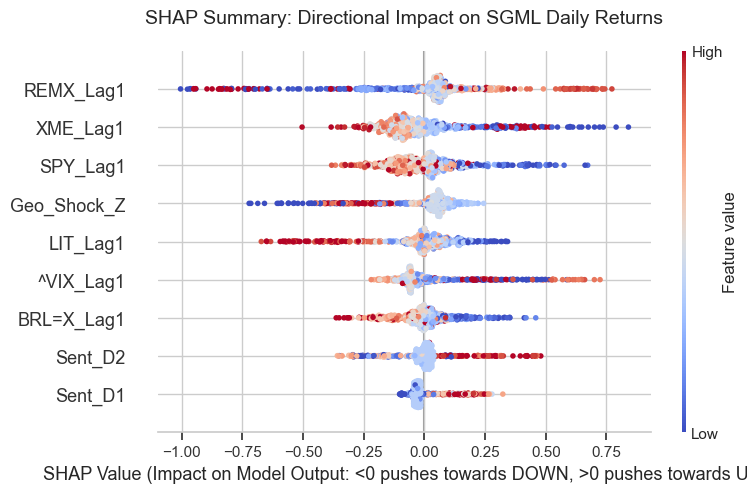

In [ ]:
# ==============================================================================
# Feature Importance via SHAP Values
# ==============================================================================
import shap
import matplotlib.pyplot as plt

print("Calculating Shapley Values (Game Theory XAI)...")

# 1. Initialize the TreeExplainer for LightGBM
explainer = shap.TreeExplainer(final_model)

# 2. Calculate SHAP values for the entire feature space
shap_values = explainer.shap_values(X)

# LightGBM binary classification sometimes returns a list of arrays (one for each class). 
# We want the explanations for Class 1 (Target = 1 / "Up Day")
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# 3. Generate the SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: Directional Impact on SGML Daily Returns", fontsize=14, pad=20)

# The core SHAP plot
shap.summary_plot(
    shap_values_to_plot, 
    X, 
    plot_type="dot", 
    show=False, # We set show=False to customize the plot before rendering
    cmap=plt.get_cmap("coolwarm") # Blue for Low feature value, Red for High feature value
)

# Professional formatting tweaks
plt.xlabel("SHAP Value (Impact on Model Output: <0 pushes towards DOWN, >0 pushes towards UP)")
plt.tight_layout()
plt.show()

### 12.1 Concluding Insights: Deconstructing the SHAP Analysis

**Objective:** Translate the mathematical feature importance (Shapley Values) into actionable economic and quantitative insights.

**Key Findings from the SHAP Beeswarm Plot:**

* **1. Market Beta Dominates the Short-Term:** The model heavily relies on broad sector momentum (`REMX_Lag1`, `XME_Lag1`) and general market beta (`SPY_Lag1`) to predict daily movements. This confirms that highly volatile mining stocks are primarily swept up by macro market tides on a day-to-day basis.
* **2. The Geopolitical Signal has True Alpha (Information):** Crucially, our engineered `Geo_Shock_Z` ranks as the **4th most important feature** in the model, outperforming traditional proxies like the Lithium ETF (`LIT_Lag1`), market volatility (`^VIX_Lag1`), and even the local currency exchange rate (`BRL=X_Lag1`). This statistically validates that tracking US-China supply chain tensions via NLP extracts unique predictive value not found in standard financial time series.
* **3. The Direction of the Shock (Risk-Off vs. Friendshoring):** Looking at the color distribution for `Geo_Shock_Z`, high values of geopolitical stress (red dots) predominantly push the SHAP value to the *left* (negative impact on the model's output). This reveals a profound market dynamic: in the immediate short-term (D+1), a geopolitical shock triggers a general "risk-off" liquidity flight, penalizing emerging market assets regardless of their structural advantages. 

**Final Conclusion for the "Friendshoring" Hypothesis:**
While the geopolitical signal is highly relevant, the *friendshoring* premium where capital strategically reallocates to Brazil as a safe-haven jurisdiction is not a high-frequency (T+1) phenomenon. To capture the positive price action of friendshoring, future iterations of this research should explore longer predictive horizons (e.g., 5-day or 15-day forward returns) where institutional capital has the time to systematically rotate out of China-exposed assets and into South American alternatives.